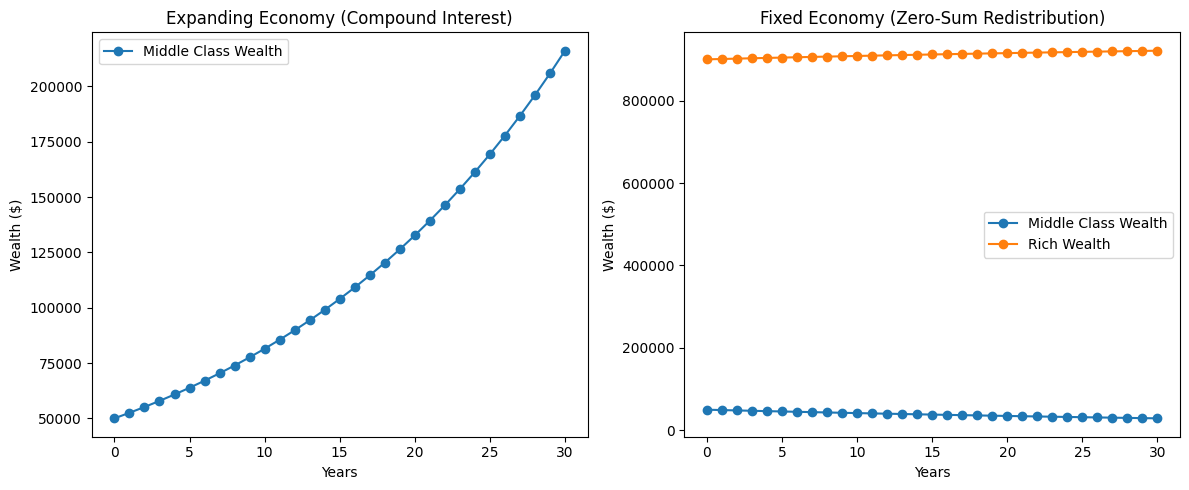

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Scenario 1: Expanding Economy
# -----------------------------
years = np.arange(0, 31)  # 0 to 30 years
r = 0.05                 # 5% annual growth
initial_wealth = 50000   # initial wealth for the middle class worker

# Compound interest formula: W = W0 * (1 + r)^t
wealth_expanding = initial_wealth * (1 + r) ** years

# -----------------------------
# Scenario 2: Fixed Economy
# -----------------------------
# Suppose total wealth is fixed at 950,000, with initial distribution:
# Middle class: 50,000, Rich: 900,000.
# Let the middle class compound at 5% and the rich at 7% (reflecting their advantage).
W_total = 950000
W_m = [50000]   # middle class wealth over time
W_r = [900000]  # rich wealth over time
r_m = 0.05      # middle class growth rate
r_r = 0.07      # rich growth rate
years_fixed = 30

# At each time step, calculate nominal growth and then re-normalize so the total remains fixed.
for t in range(years_fixed):
    new_W_m = W_m[-1] * (1 + r_m)
    new_W_r = W_r[-1] * (1 + r_r)
    total_new = new_W_m + new_W_r
    # Reallocate (normalize) to keep total wealth fixed
    new_W_m = new_W_m / total_new * W_total
    new_W_r = new_W_r / total_new * W_total
    W_m.append(new_W_m)
    W_r.append(new_W_r)

years_list = np.arange(0, years_fixed + 1)

# -----------------------------
# Plotting the results
# -----------------------------
plt.figure(figsize=(12, 5))

# Plot for the Expanding Economy
plt.subplot(1, 2, 1)
plt.plot(years, wealth_expanding, marker='o', label='Middle Class Wealth')
plt.title('Expanding Economy (Compound Interest)')
plt.xlabel('Years')
plt.ylabel('Wealth ($)')
plt.legend()

# Plot for the Fixed Economy
plt.subplot(1, 2, 2)
plt.plot(years_list, W_m, marker='o', label='Middle Class Wealth')
plt.plot(years_list, W_r, marker='o', label='Rich Wealth')
plt.title('Fixed Economy (Zero-Sum Redistribution)')
plt.xlabel('Years')
plt.ylabel('Wealth ($)')
plt.legend()

plt.tight_layout()
plt.show()


Explanation

Scenario 1 (Equal Tech Benefit):

Both the middle class and the rich have the same growth rate (5%), so even though wealth grows, the distribution remains stable because both groups benefit equally.

Scenario 2 (Differential Tech Benefit):

Here, we add a tech factor (2%). The middle class gets only 50% of this benefit (raising their growth rate to 0.05 + 0.01 = 6%), while the rich get 150% of the benefit (raising their growth rate to 0.05 + 0.03 = 8%). When we simulate over time with a fixed total wealth (normalizing the distribution at each step), the rich's share increases at the expense of the middle class.

This simulation shows that, in a fixed-size economy, if technological expansion disproportionately benefits the rich, it can widen the wealth gap—even if compound interest works in favor of everyone in an expanding economy.

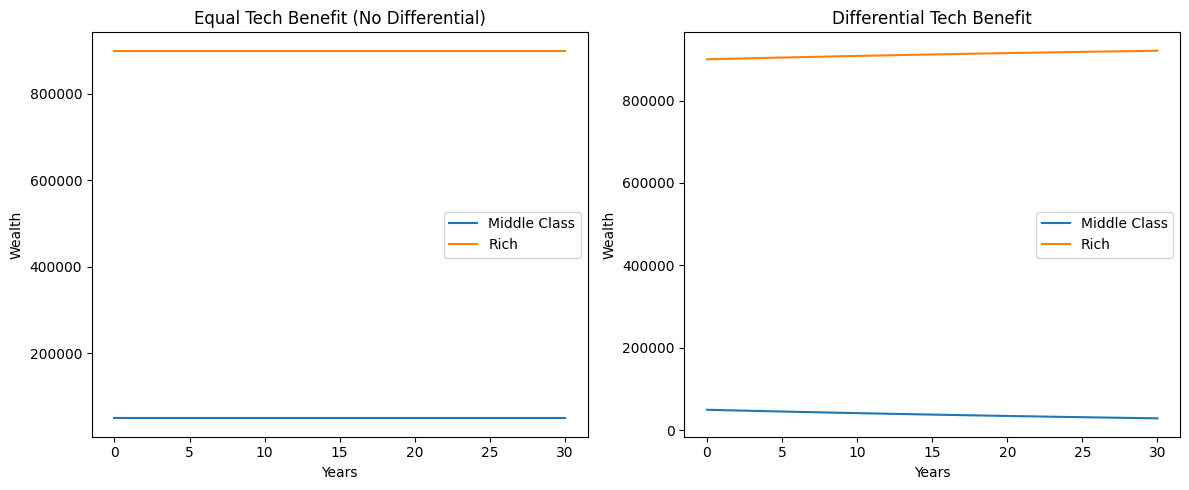

In [3]:
import numpy as np
import matplotlib.pyplot as plt

years = 30
W_total = 950000

# Initial wealth distribution:
W_middle = 50000   # Middle-class initial wealth
W_rich   = 900000  # Rich initial wealth

# Baseline growth rate (without tech benefits)
base_growth = 0.05

# ---------------------------
# Scenario 1: No Differential Tech Benefit
# ---------------------------
# Both groups benefit equally from technology
growth_middle_equal = base_growth
growth_rich_equal   = base_growth

Wm_equal = [W_middle]
Wr_equal = [W_rich]
for t in range(years):
    new_Wm = Wm_equal[-1] * (1 + growth_middle_equal)
    new_Wr = Wr_equal[-1] * (1 + growth_rich_equal)
    total = new_Wm + new_Wr
    # Normalize to keep total wealth fixed:
    new_Wm = new_Wm / total * W_total
    new_Wr = new_Wr / total * W_total
    Wm_equal.append(new_Wm)
    Wr_equal.append(new_Wr)

# ---------------------------
# Scenario 2: Differential Tech Benefits
# ---------------------------
# Here, technology adds extra growth, but the rich capture a larger share.
tech_factor = 0.02   # extra growth from technology
# Benefit multipliers: middle class gets 0.5 of tech benefit, rich gets 1.5 times.
benefit_multiplier_middle = 0.5  
benefit_multiplier_rich   = 1.5

growth_middle_diff = base_growth + tech_factor * benefit_multiplier_middle
growth_rich_diff   = base_growth + tech_factor * benefit_multiplier_rich

Wm_diff = [W_middle]
Wr_diff = [W_rich]
for t in range(years):
    new_Wm = Wm_diff[-1] * (1 + growth_middle_diff)
    new_Wr = Wr_diff[-1] * (1 + growth_rich_diff)
    total = new_Wm + new_Wr
    new_Wm = new_Wm / total * W_total
    new_Wr = new_Wr / total * W_total
    Wm_diff.append(new_Wm)
    Wr_diff.append(new_Wr)

# ---------------------------
# Plotting the results
# ---------------------------
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(np.arange(years+1), Wm_equal, label='Middle Class')
plt.plot(np.arange(years+1), Wr_equal, label='Rich')
plt.title('Equal Tech Benefit (No Differential)')
plt.xlabel('Years')
plt.ylabel('Wealth')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(np.arange(years+1), Wm_diff, label='Middle Class')
plt.plot(np.arange(years+1), Wr_diff, label='Rich')
plt.title('Differential Tech Benefit')
plt.xlabel('Years')
plt.ylabel('Wealth')
plt.legend()

plt.tight_layout()
plt.show()
